<h2><center> 🛡️ 👾 Cybersecurity Attacks & Defense – Analytical Threat Intelligence System in a Modern Cyber Battlefield 🐛 🌐 </center></h2>

<h4><center> From Raw Exchange To Security Insights: Machine - Deep Learning & Predictive Analytics & Real-World Protection </center></h4>

<p><b>Dataset Author:</b> Uneeb, Z. (2026). </p>

<p><b>Official Sources:</b>
<a href="https://otx.alienvault.com/" target="_blank">AlienVault OTX</a>,
<a href="https://www.cisa.gov/known-exploited-vulnerabilities-catalog" target="_blank">CISA KEV Catalog</a>,
<a href="https://nvd.nist.gov/" target="_blank">NVD (National Vulnerability Database)</a></p>

<p><b> Launch Date:</b> May 13rd - 14th, 2026 </p>

<p><b>Successors</b>:
    <ul>
        <li> Tolstoy, J. (2026). <i> CVE Ransomware Risk Modeling </i>. Kaggle. <a href="https://www.kaggle.com/code/tolstoyjustin/cve-ransomware-risk-modeling" target="_blank">[Repository]</a></li>
        <li> Tolstoy, J. (2026). <i> OTX NLP / MITRE ATT&CK Mapping </i>. Kaggle. <a href = "https://www.kaggle.com/code/tolstoyjustin/otx-nlp-mitre-att-ck-mapping"> [Repository]</a></li>
        <li> Uneeb, Z. (2026). <i> Cybersecurity Threat Intelligence - EDA & Analysis </i>. Kaggle. <a href = "https://www.kaggle.com/code/chuneeb/cybersecurity-threat-intelligence-eda-analysis">[Repository]</a></li>
    </ul>
</p>

<p><b>Hackathon Contestant:</b> Cresht </p>

### Imports ###

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, re, ast, squarify
from collections import Counter
from pathlib import Path

In [2]:
# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# User configs
from configs.paths import RAW_DIR, INTERIM_DIR, FIG_DIR
from src.utils import standardize_columns, safe_to_datetime, normalize_text

### Load CSV Files ###

In [3]:
otx = pd.read_csv(RAW_DIR / "1_otx_threat_intel.csv")
cve = pd.read_csv(RAW_DIR / "2_cve_vulnerabilities.csv")
domains = pd.read_csv(RAW_DIR / "3_malicious_domains.csv")
ips = pd.read_csv(RAW_DIR / "4_malicious_ips.csv")

print("OTX shape:", otx.shape)
print("CVE shape:", cve.shape)
print("Domains shape:", domains.shape)
print("IPs shape:", ips.shape)

OTX shape: (2365, 14)
CVE shape: (1585, 10)
Domains shape: (162, 20)
IPs shape: (200, 20)


### Standardize Column Names ###

In [4]:
otx = standardize_columns(otx)
cve = standardize_columns(cve)
domains = standardize_columns(domains)
ips = standardize_columns(ips)

otx.columns, cve.columns, domains.columns, ips.columns

(Index(['Pulse_ID', 'Title', 'Description', 'Author', 'Created', 'Modified',
        'TLP', 'Tags', 'Malware_Families', 'Attack_IDs', 'Industries',
        'Countries', 'Indicators_Count', 'Subscribers'],
       dtype='str'),
 Index(['cveID', 'vendorProject', 'product', 'vulnerabilityName', 'dateAdded',
        'shortDescription', 'requiredAction', 'dueDate',
        'knownRansomwareCampaignUse', 'cwes'],
       dtype='str'),
 Index(['Domain', 'TLD', 'Domain_Length', 'Has_Numbers', 'Has_Hyphen',
        'Registrar', 'Creation_Date', 'Last_Update_Date', 'Reputation',
        'Malicious_Votes', 'Suspicious_Votes', 'Harmless_Votes',
        'Undetected_Votes', 'Total_Engines', 'Threat_Severity', 'Categories',
        'Popularity_Rank', 'Last_Analysis_Date', 'WHOIS_Summary',
        'Data_Source'],
       dtype='str'),
 Index(['IP', 'Country', 'Continent', 'ASN', 'Owner', 'Network',
        'Malicious_Votes', 'Suspicious_Votes', 'Harmless_Votes',
        'Undetected_Votes', 'Total_Reports'

### Structural Inspection ###

In [5]:
def inspect_df(df, name):
    print(f"\n========================= {name} =========================")
    display(df.head(3))
    print(df.info())
    display(df.describe(include = "all").T)
    print("Missing values:\n", df.isna().sum().sort_values(ascending = False).head(10))
    print("Duplicates:", df.duplicated().sum())

inspect_df(otx, "OTX")
inspect_df(cve, "CVE")
inspect_df(domains, "Domains")
inspect_df(ips, "IPs")


========================= OTX =========================


,Pulse_ID,Title,Description,Author,Created,Modified,TLP,Tags,Malware_Families,Attack_IDs,Industries,Countries,Indicators_Count,Subscribers
0,69f1e236e4e192f639298d53,Multi-Stage Malware Execution Chain Analysis,A sophisticated multi-stage malware execution ...,AlienVault,2026-04-29T10:49:26.327000,2026-04-29T10:50:57.999000,white,"payload extraction, c2 communication, defense ...",Unknown,"T1036.005, T1082, T1071, T1140, T1036, T1055, ...",Unknown,Unknown,0.0,0.0
1,69f1de85544538ce8b03332a,User interaction with a ClickFix-style phishin...,A ClickFix-style phishing campaign leveraged s...,AlienVault,2026-04-29T10:33:41.967000,2026-04-29T10:44:36.742000,white,"phishing, lumma stealer, powershell, informati...","HijackLoader, Lumma Stealer - S1213, LummaStealer","T1218.007, T1005, T1555, T1036, T1055, T1059, ...",Unknown,Unknown,0.0,0.0
2,69f1d20216d6091f01f8a6eb,Kyber ransomware is not just post-quantum name...,A detailed technical analysis confirms that Ky...,AlienVault,2026-04-29T09:40:17.996000,2026-04-29T10:14:38.724000,white,"post-quantum cryptography, x25519, aes-ctr enc...",Kyber,"T1489, T1135, T1082, T1112, T1070.001, T1222, ...","Defense, Technology",United States of America,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 2365 entries, 0 to 2364
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pulse_ID          2365 non-null   str    
 1   Title             2365 non-null   str    
 2   Description       2364 non-null   str    
 3   Author            2365 non-null   str    
 4   Created           2365 non-null   str    
 5   Modified          2365 non-null   str    
 6   TLP               2365 non-null   str    
 7   Tags              2365 non-null   str    
 8   Malware_Families  2365 non-null   str    
 9   Attack_IDs        2365 non-null   str    
 10  Industries        2365 non-null   str    
 11  Countries         2365 non-null   str    
 12  Indicators_Count  2365 non-null   float64
 13  Subscribers       2365 non-null   float64
dtypes: float64(2), str(12)
memory usage: 1.9 MB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Pulse_ID,2365,2340,69f1e236e4e192f639298d53,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,2365,2286,Multi-Stage Malware Execution Chain Analysis,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,2364,2361,These indicators of compromise (IOCs) were ide...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Author,2365,1,AlienVault,2365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Created,2365,2340,2026-04-29T10:49:26.327000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Modified,2365,2085,2025-01-06T23:11:01.995000,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TLP,2365,2,white,2362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tags,2365,2329,Unknown,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Malware_Families,2365,1457,Unknown,656,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attack_IDs,2365,2129,Unknown,189,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values:
 Description         1
Pulse_ID            0
Title               0
Author              0
Created             0
Modified            0
TLP                 0
Tags                0
Malware_Families    0
Attack_IDs          0
dtype: int64
Duplicates: 0

========================= CVE =========================


...

Missing values:
 Domain              0
TLD                 0
Domain_Length       0
Has_Numbers         0
Has_Hyphen          0
Registrar           0
Creation_Date       0
Last_Update_Date    0
Reputation          0
Malicious_Votes     0
dtype: int64
Duplicates: 0

========================= IPs =========================


,IP,Country,Continent,ASN,Owner,Network,Malicious_Votes,Suspicious_Votes,Harmless_Votes,Undetected_Votes,Total_Reports,Reputation_Score,Threat_Label,Threat_Category,Regional_Registry,WHOIS_Summary,TOR_Node,Times_Submitted,Last_Analysis_Date,Threat_Severity
0,176.10.99.200,CH,EU,51395.0,Datasource AG,176.10.96.0/19,3,0,55,33,91,-26,clean,clean,RIPE NCC,inetnum: 176.10.99.192 - 176.10.99.223\nnetnam...,No,0,1777589108,Low
1,176.10.99.201,CH,EU,51395.0,Datasource AG,176.10.96.0/19,0,1,53,37,91,0,unrated,clean,RIPE NCC,inetnum: 176.10.99.192 - 176.10.99.223\nnetnam...,No,0,1776571431,Low
2,77.247.181.162,NL,EU,43350.0,NForce Entertainment B.V.,77.247.176.0/21,4,1,53,33,91,-19,unrated,clean,RIPE NCC,inetnum: 77.247.181.160 - 77.247.181.175\nnetn...,No,0,1777589035,Medium


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   IP                  200 non-null    str  
 1   Country             200 non-null    str  
 2   Continent           200 non-null    str  
 3   ASN                 200 non-null    str  
 4   Owner               200 non-null    str  
 5   Network             200 non-null    str  
 6   Malicious_Votes     200 non-null    int64
 7   Suspicious_Votes    200 non-null    int64
 8   Harmless_Votes      200 non-null    int64
 9   Undetected_Votes    200 non-null    int64
 10  Total_Reports       200 non-null    int64
 11  Reputation_Score    200 non-null    int64
 12  Threat_Label        200 non-null    str  
 13  Threat_Category     200 non-null    str  
 14  Regional_Registry   200 non-null    str  
 15  WHOIS_Summary       200 non-null    str  
 16  TOR_Node            200 non-null    str  
 17  Times_Su

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
IP,200,200,176.10.99.200,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,200,24,DE,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Continent,200,4,EU,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASN,200,31,12876.0,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,200,30,Scaleway SAS,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Network,200,53,Unknown,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Malicious_Votes,200.0,NaN,NaN,NaN,1.5,3.692992,0.0,0.0,0.0,1.0,21.0
Suspicious_Votes,200.0,NaN,NaN,NaN,0.295,0.742111,0.0,0.0,0.0,0.0,4.0
Harmless_Votes,200.0,NaN,NaN,NaN,24.285,26.276148,0.0,0.0,0.0,54.0,58.0
Undetected_Votes,200.0,NaN,NaN,NaN,64.92,28.099493,28.0,35.0,91.0,91.0,91.0


Missing values:
 IP                  0
Country             0
Continent           0
ASN                 0
Owner               0
Network             0
Malicious_Votes     0
Suspicious_Votes    0
Harmless_Votes      0
Undetected_Votes    0
dtype: int64
Duplicates: 0


### Convert Date Columns ###

In [6]:
# OTX
for col in ["Created", "Modified"]:
    if col in otx.columns:
        otx[col] = safe_to_datetime(otx[col])

# CVE
for col in ["dateAdded", "dueDate"]:
    if col in cve.columns:
        cve[col] = safe_to_datetime(cve[col])

# Domains
for col in ["Creation_Date", "Last_Update_Date"]:
    if col in domains.columns:
        domains[col] = safe_to_datetime(domains[col])

if "Last_Analysis_Date" in domains.columns:
    domains["Last_Analysis_Date"] = safe_to_datetime(domains["Last_Analysis_Date"])

# IPs
if "Last_Analysis_Date" in ips.columns:
    ips["Last_Analysis_Date"] = safe_to_datetime(ips["Last_Analysis_Date"])

c:\Users\Admin\Documents\GitHub\data_science\src\utils.py:62: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  result.loc[~is_unix] = pd.to_datetime(


In [7]:
# Display samples for each dataset
for name, df in {"OTX": otx, "CVE": cve, "Domains": domains, "IPs": ips}.items():
    print(f"\n========================= {name} =========================")
    display(df.head())


========================= OTX =========================


,Pulse_ID,Title,Description,Author,Created,Modified,TLP,Tags,Malware_Families,Attack_IDs,Industries,Countries,Indicators_Count,Subscribers
0,69f1e236e4e192f639298d53,Multi-Stage Malware Execution Chain Analysis,A sophisticated multi-stage malware execution ...,AlienVault,2026-04-29 10:49:26.327,2026-04-29 10:50:57.999,white,"payload extraction, c2 communication, defense ...",Unknown,"T1036.005, T1082, T1071, T1140, T1036, T1055, ...",Unknown,Unknown,0.0,0.0
1,69f1de85544538ce8b03332a,User interaction with a ClickFix-style phishin...,A ClickFix-style phishing campaign leveraged s...,AlienVault,2026-04-29 10:33:41.967,2026-04-29 10:44:36.742,white,"phishing, lumma stealer, powershell, informati...","HijackLoader, Lumma Stealer - S1213, LummaStealer","T1218.007, T1005, T1555, T1036, T1055, T1059, ...",Unknown,Unknown,0.0,0.0
2,69f1d20216d6091f01f8a6eb,Kyber ransomware is not just post-quantum name...,A detailed technical analysis confirms that Ky...,AlienVault,2026-04-29 09:40:17.996,2026-04-29 10:14:38.724,white,"post-quantum cryptography, x25519, aes-ctr enc...",Kyber,"T1489, T1135, T1082, T1112, T1070.001, T1222, ...","Defense, Technology",United States of America,0.0,0.0
3,69f1d26f3c7a8e098eccb448,Rebex-based Telegram RAT Targeting Vietnam,A sophisticated CHM-based malware campaign has...,AlienVault,2026-04-29 09:42:07.871,2026-04-29 10:13:37.390,white,"multi-stage payload, telegram rat, chm infecti...",Unknown,"T1053.005, T1036.005, T1204.002, T1497.001, T1...",Unknown,Unknown,0.0,0.0
4,69f1d2d45ec26fc5e1ca72f4,KYCShadow: An Android Banking Malware Exploiti...,An Android malware campaign masquerading as a ...,AlienVault,2026-04-29 09:43:48.542,2026-04-29 10:12:57.758,white,"india targeting, android banking trojan, otp t...",KYCShadow,Unknown,Finance,"British Indian Ocean Territory, India",0.0,0.0



========================= CVE =========================


,cveID,vendorProject,product,vulnerabilityName,dateAdded,shortDescription,requiredAction,dueDate,knownRansomwareCampaignUse,cwes
0,CVE-2024-1708,ConnectWise,ScreenConnect,ConnectWise ScreenConnect Path Traversal Vulne...,2026-04-28,ConnectWise ScreenConnect contains a path trav...,"Apply mitigations per vendor instructions, fol...",2026-05-12,Unknown,CWE-22
1,CVE-2026-32202,Microsoft,Windows,Microsoft Windows Protection Mechanism Failure...,2026-04-28,Microsoft Windows Shell contains a protection ...,"Apply mitigations per vendor instructions, fol...",2026-05-12,Unknown,CWE-693
2,CVE-2025-29635,D-Link,DIR-823X,D-Link DIR-823X Command Injection Vulnerability,2026-04-24,D-Link DIR-823X contains a command injection v...,"Apply mitigations per vendor instructions, fol...",2026-05-08,Unknown,CWE-77
3,CVE-2024-7399,Samsung,MagicINFO 9 Server,Samsung MagicINFO 9 Server Path Traversal Vuln...,2026-04-24,Samsung MagicINFO 9 Server contains a path tra...,"Apply mitigations per vendor instructions, fol...",2026-05-08,Unknown,"CWE-22, CWE-434"
4,CVE-2024-57728,SimpleHelp,SimpleHelp,SimpleHelp Path Traversal Vulnerability,2026-04-24,SimpleHelp contains a path traversal vulnerabi...,"Apply mitigations per vendor instructions, fol...",2026-05-08,Unknown,CWE-22



========================= Domains =========================


,Domain,TLD,Domain_Length,Has_Numbers,Has_Hyphen,Registrar,Creation_Date,Last_Update_Date,Reputation,Malicious_Votes,Suspicious_Votes,Harmless_Votes,Undetected_Votes,Total_Engines,Threat_Severity,Categories,Popularity_Rank,Last_Analysis_Date,WHOIS_Summary,Data_Source
0,urlhaus.abuse.ch,ch,16,No,No,Unknown,NaT,NaT,2,0,0,59,32,91,Low,{},Unknown,2026-05-01 12:01:25,DNSSEC:Y,VirusTotal
1,bazaar.abuse.ch,ch,15,No,No,Unknown,NaT,NaT,6,1,0,58,32,91,Low,{},Unknown,2026-05-01 12:02:29,DNSSEC:Y,VirusTotal
2,feodotracker.abuse.ch,ch,21,No,No,Unknown,NaT,NaT,1,0,0,59,32,91,Low,{},Unknown,2026-05-01 09:28:32,DNSSEC:Y,VirusTotal
3,sslbl.abuse.ch,ch,14,No,No,Unknown,NaT,NaT,0,0,0,59,32,91,Low,{},Unknown,2026-05-01 03:02:32,DNSSEC:Y,VirusTotal
4,threatfox.abuse.ch,ch,18,No,No,Unknown,NaT,NaT,0,0,0,58,33,91,Low,{},Unknown,2026-05-01 12:14:42,DNSSEC:Y,VirusTotal



========================= IPs =========================


,IP,Country,Continent,ASN,Owner,Network,Malicious_Votes,Suspicious_Votes,Harmless_Votes,Undetected_Votes,Total_Reports,Reputation_Score,Threat_Label,Threat_Category,Regional_Registry,WHOIS_Summary,TOR_Node,Times_Submitted,Last_Analysis_Date,Threat_Severity
0,176.10.99.200,CH,EU,51395.0,Datasource AG,176.10.96.0/19,3,0,55,33,91,-26,clean,clean,RIPE NCC,inetnum: 176.10.99.192 - 176.10.99.223\nnetnam...,No,0,2026-04-30 22:45:08,Low
1,176.10.99.201,CH,EU,51395.0,Datasource AG,176.10.96.0/19,0,1,53,37,91,0,unrated,clean,RIPE NCC,inetnum: 176.10.99.192 - 176.10.99.223\nnetnam...,No,0,2026-04-19 04:03:51,Low
2,77.247.181.162,NL,EU,43350.0,NForce Entertainment B.V.,77.247.176.0/21,4,1,53,33,91,-19,unrated,clean,RIPE NCC,inetnum: 77.247.181.160 - 77.247.181.175\nnetn...,No,0,2026-04-30 22:43:55,Medium
3,77.247.181.163,NL,EU,43350.0,NForce Entertainment B.V.,77.247.176.0/21,2,2,55,32,91,-16,clean,clean,RIPE NCC,inetnum: 77.247.181.160 - 77.247.181.175\nnetn...,No,0,2026-04-30 22:38:58,Low
4,199.87.154.255,CA,Unknown,18451.0,LES.NET,199.87.152.0/21,2,0,54,35,91,-1,unrated,clean,ARIN,LES.NET LESNET-V4-2 (NET-199-87-152-0-1) 199.8...,No,0,2026-04-30 22:27:59,Low


### Lightweight Engineering ###

In [8]:
def add_date_parts(df, col):
    if col in df.columns:
        df[f"{col}_year"] = df[col].dt.year
        df[f"{col}_month"] = df[col].dt.month
        df[f"{col}_day"] = df[col].dt.day

add_date_parts(otx, "Created")
add_date_parts(cve, "dateAdded")
add_date_parts(domains, "Creation_Date")
add_date_parts(ips, "Last_Analysis_Date")

In [9]:
def extract_cwes(x):
    if pd.isna(x):
        return []
    return re.findall(r"CWE-\d+", str(x))

cve["cwe_list"] = cve["cwes"].apply(extract_cwes)
cwe_counts = (
    cve.explode("cwe_list")
       .dropna(subset=["cwe_list"])
       .groupby("cwe_list")
       .size()
       .sort_values(ascending=False)
)

In [10]:
# Safe parser
def safe_parse(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else {}
    except:
        return {}

# Parse safely
parsed_categories = domains["Categories"].apply(safe_parse)

# Flatten category values
all_categories = []

for d in parsed_categories:
    if isinstance(d, dict):
        all_categories.extend(d.values())

# Count top categories
top_categories = Counter(all_categories).most_common(10)

# DataFrame
top_categories_df = pd.DataFrame(
    top_categories,
    columns=["Category", "Count"]
)

### Cardinality Check ###

In [11]:
def cardinality_report(df, name):
    cat_cols = df.select_dtypes(include=["object", "string"]).columns

    def make_hashable(x):
        if isinstance(x, list):
            return tuple(x)
        if isinstance(x, dict):
            return str(x)
        return x

    report = pd.DataFrame({
        "column": cat_cols,
        "nunique": [
            df[c].map(make_hashable).nunique(dropna=True)
            for c in cat_cols
        ]
    }).sort_values("nunique", ascending=False)

    print(f"\n{name} cardinality report")
    display(report.head(20))

cardinality_report(otx, "OTX")
cardinality_report(cve, "CVE")
cardinality_report(domains, "Domains")
cardinality_report(ips, "IPs")


OTX cardinality report


,column,nunique
2,Description,2361
0,Pulse_ID,2340
5,Tags,2329
1,Title,2286
7,Attack_IDs,2129
6,Malware_Families,1457
9,Countries,530
8,Industries,470
4,TLP,2
3,Author,1



CVE cardinality report


,column,nunique
0,cveID,1585
4,shortDescription,1498
3,vulnerabilityName,1257
2,product,642
1,vendorProject,258
8,cwe_list,228
7,cwes,228
5,requiredAction,42
6,knownRansomwareCampaignUse,2



Domains cardinality report


,column,nunique
0,Domain,162
8,WHOIS_Summary,123
7,Popularity_Rank,75
4,Registrar,53
6,Categories,29
1,TLD,24
5,Threat_Severity,3
3,Has_Hyphen,2
2,Has_Numbers,2
9,Data_Source,1



IPs cardinality report


,column,nunique
0,IP,200
9,WHOIS_Summary,83
5,Network,53
3,ASN,31
4,Owner,30
1,Country,24
8,Regional_Registry,5
2,Continent,4
7,Threat_Category,3
6,Threat_Label,3


### Compact Visualisation ###

#### 1. Malicious Domain ####

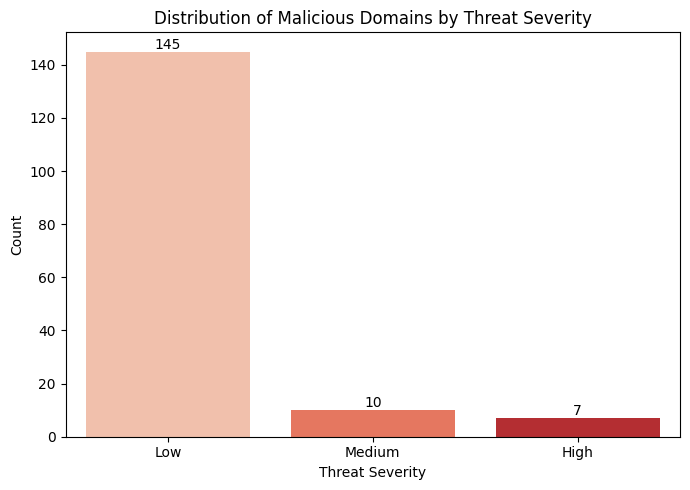

In [12]:
plt.figure(figsize=(7, 5))

severity_order = ["Low", "Medium", "High"]

sns.countplot(
    data=domains,
    x = "Threat_Severity",
    hue = "Threat_Severity",    # Add hue
    order = severity_order,
    palette="Reds",
    legend = False              # Prevent duplicated legend
)

plt.title("Distribution of Malicious Domains by Threat Severity")
plt.xlabel("Threat Severity")
plt.ylabel("Count")

for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

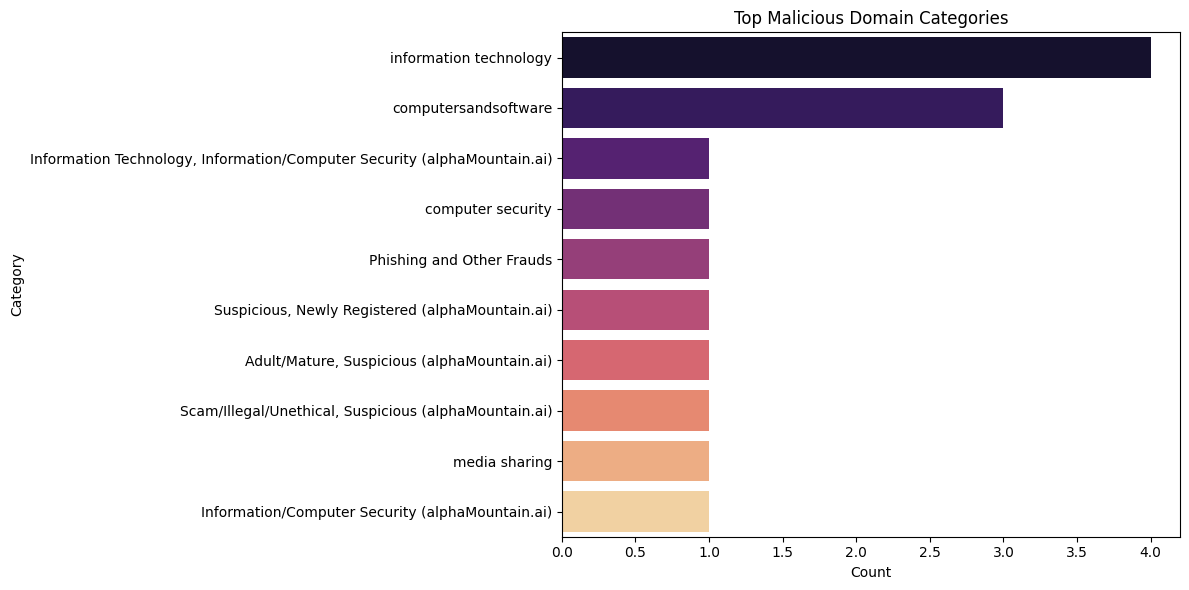

In [13]:
# Plot
plt.figure(figsize=(12, 6))

sns.barplot(data = top_categories_df, x = "Count", y = "Category", hue = "Category", palette = "magma", legend = False)

plt.title("Top Malicious Domain Categories")
plt.xlabel("Count")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

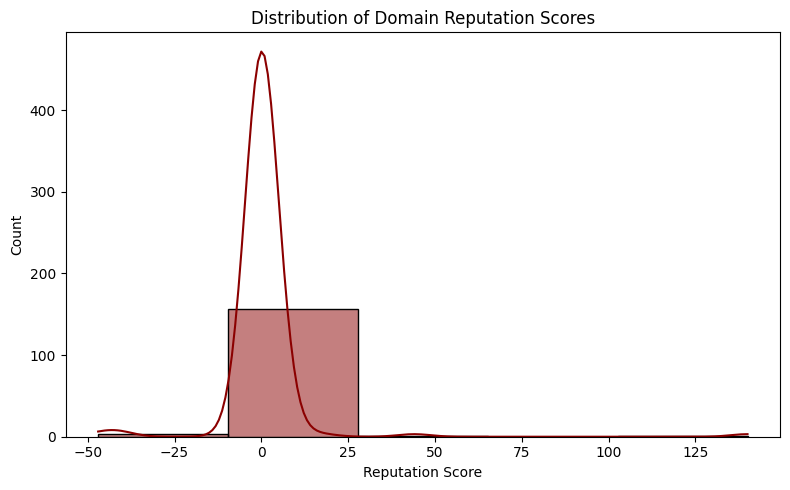

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(domains["Reputation"], bins = 5, kde = True, color = "darkred")

plt.title("Distribution of Domain Reputation Scores")
plt.xlabel("Reputation Score")

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6940\3859055727.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


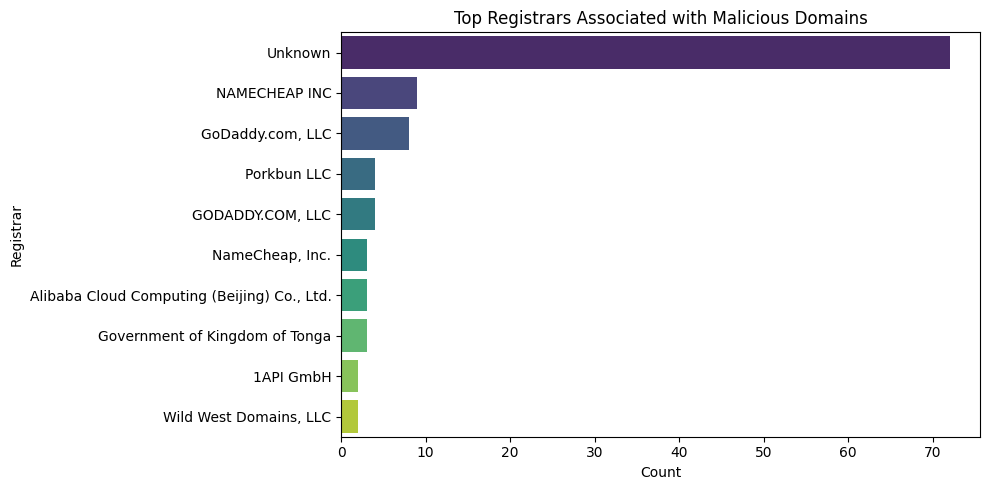

In [15]:
top_registrars = domains["Registrar"].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_registrars.values,
    y=top_registrars.index,
    palette="viridis"
)

plt.title("Top Registrars Associated with Malicious Domains")
plt.xlabel("Count")
plt.ylabel("Registrar")

plt.tight_layout()
plt.show()

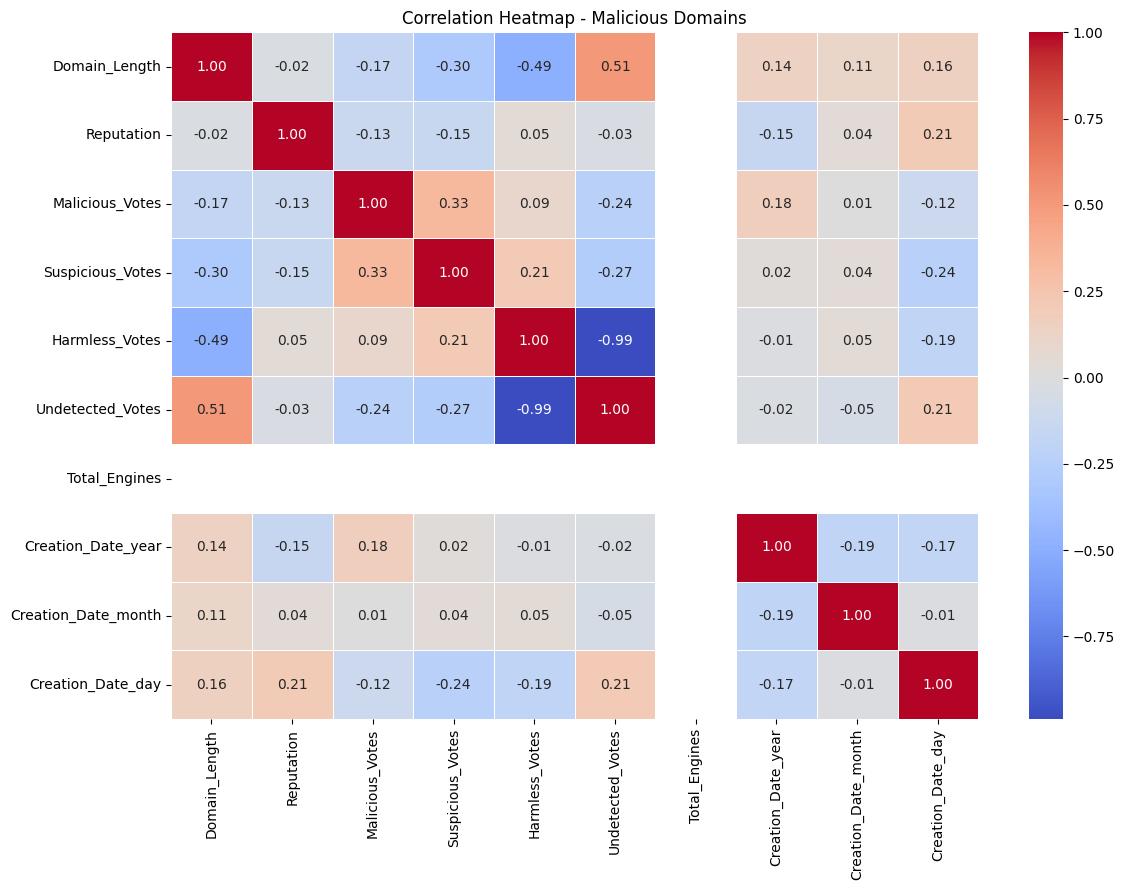

In [16]:
numeric_cols = domains.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(12, 9))

corr = domains[numeric_cols].corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap - Malicious Domains")

plt.tight_layout()
plt.show()

#### 2. CVE ####

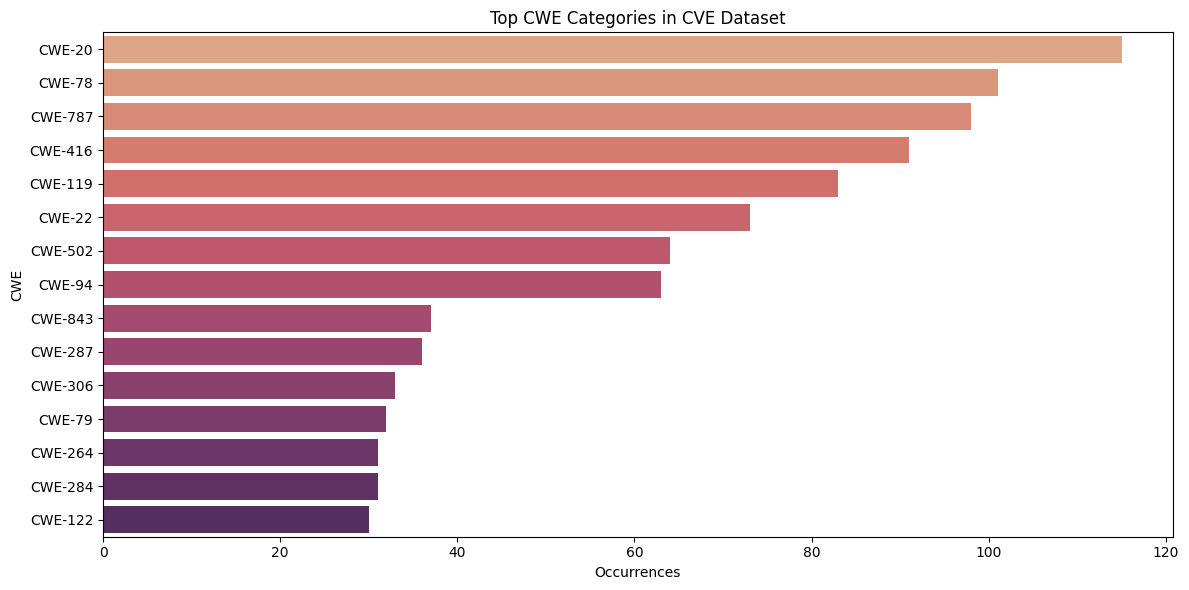

In [17]:
top_cwe = cwe_counts.head(15).reset_index()
top_cwe.columns = ["CWE", "Count"]

plt.figure(figsize=(12, 6))

sns.barplot(data = top_cwe, x = "Count", y = "CWE", hue = "CWE", palette = "flare",legend = False)

plt.title("Top CWE Categories in CVE Dataset")
plt.xlabel("Occurrences")
plt.ylabel("CWE")

plt.tight_layout()
plt.show()

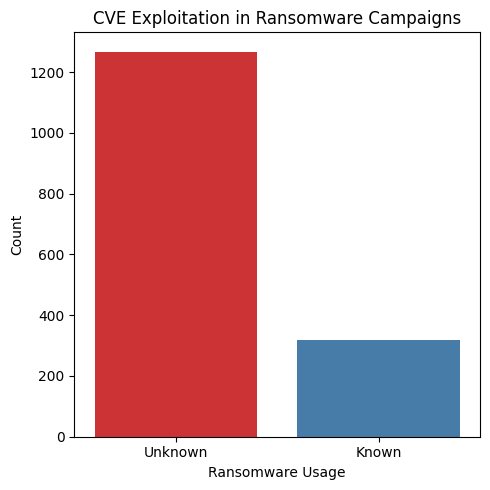

In [18]:
plt.figure(figsize=(5, 5))

sns.countplot(
    data = cve,
    x = "knownRansomwareCampaignUse",
    hue = "knownRansomwareCampaignUse",
    palette = "Set1",
    legend = False
)

plt.title("CVE Exploitation in Ransomware Campaigns")
plt.xlabel("Ransomware Usage")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

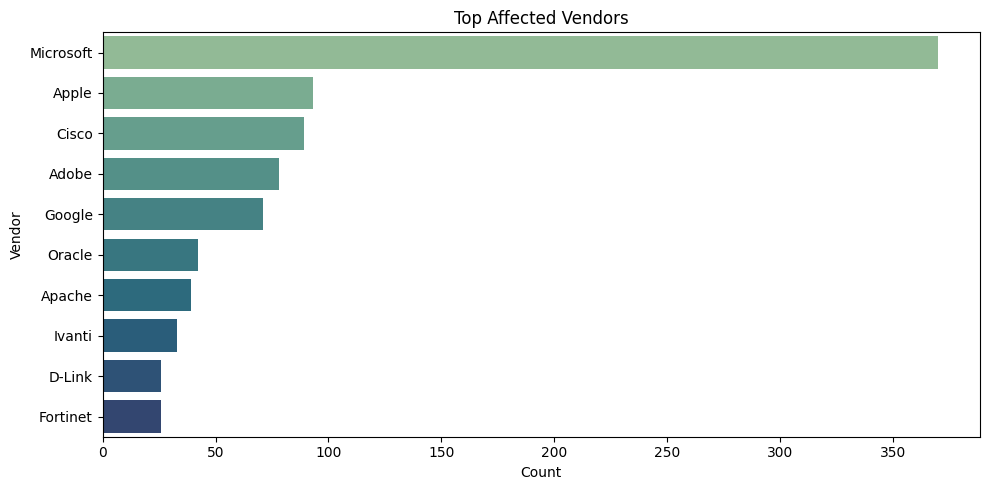

In [19]:
top_vendors = (cve["vendorProject"].value_counts().head(10).reset_index())
top_vendors.columns = ["Vendor", "Count"]

plt.figure(figsize=(10, 5))

sns.barplot(
    data = top_vendors,
    x = "Count",
    y = "Vendor",
    hue = "Vendor",
    palette = "crest",
    legend = False
)

plt.title("Top Affected Vendors")
plt.xlabel("Count")
plt.ylabel("Vendor")

plt.tight_layout()
plt.show()

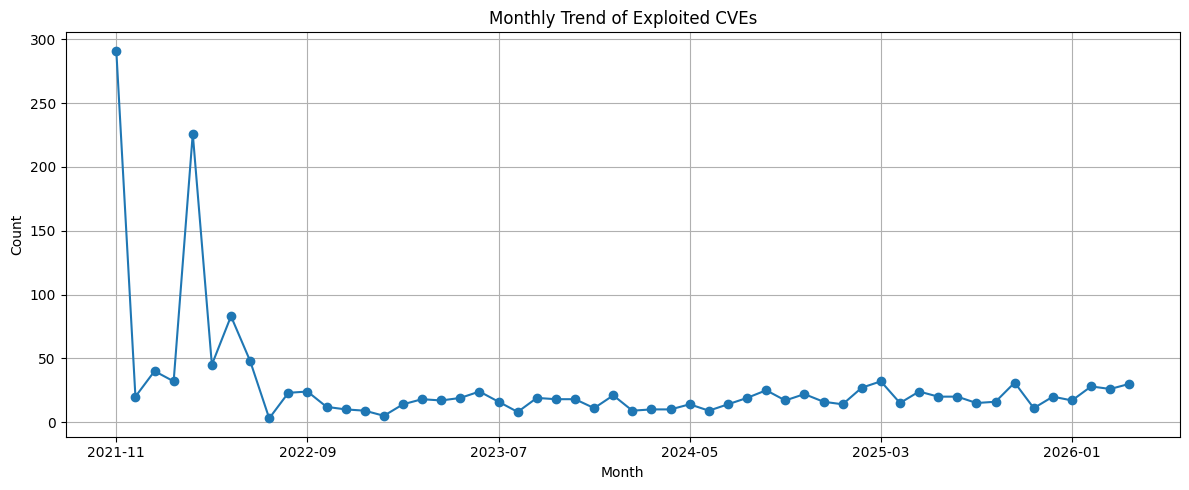

In [20]:
cve["dateAdded"] = pd.to_datetime(cve["dateAdded"]).dt.tz_localize(None)

monthly_cves = cve.groupby(cve["dateAdded"].dt.to_period("M")).size()

monthly_cves.index = monthly_cves.index.astype(str)

plt.figure(figsize=(12, 5))

monthly_cves.plot(marker="o")

plt.title("Monthly Trend of Exploited CVEs")
plt.xlabel("Month")
plt.ylabel("Count")

plt.grid(True)
plt.tight_layout()
plt.show()

### 3. OTX Threat Intelligence ###

C:\Users\Admin\AppData\Local\Temp\ipykernel_6940\3767419458.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


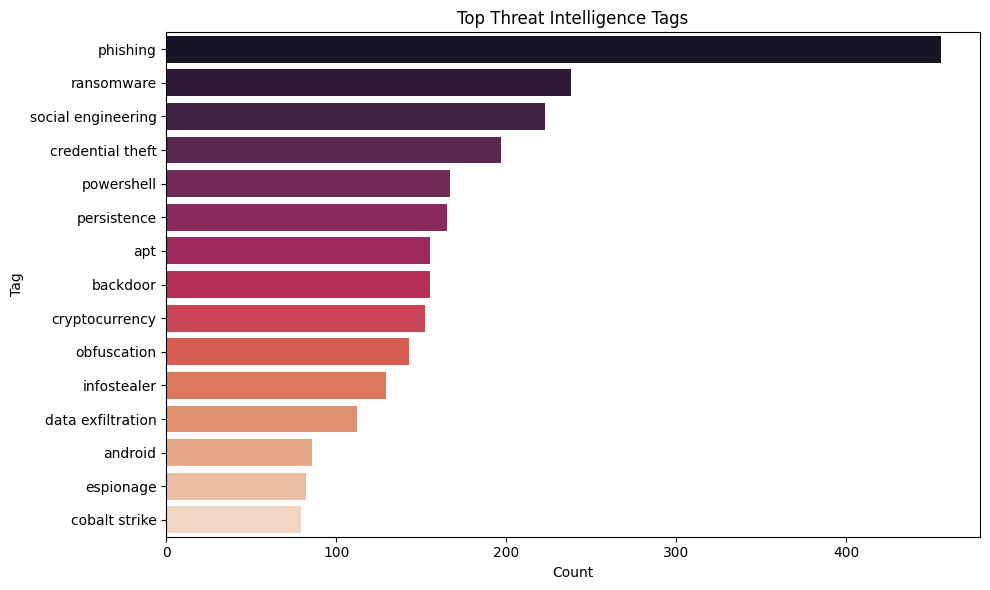

In [21]:
all_tags = ",".join(otx["Tags"].dropna()).split(",")

tag_counts = Counter([t.strip() for t in all_tags])

top_tags = pd.DataFrame(
    tag_counts.items(),
    columns=["Tag", "Count"]
).sort_values(by="Count", ascending=False).head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_tags,
    x="Count",
    y="Tag",
    palette="rocket"
)

plt.title("Top Threat Intelligence Tags")

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6940\1230484091.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


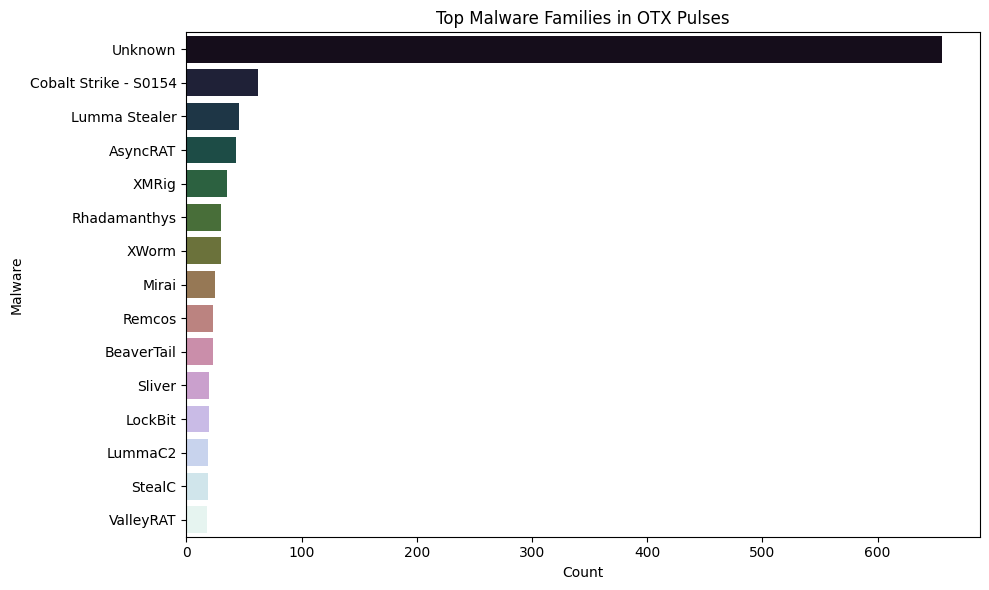

In [22]:
all_malware = ",".join(otx["Malware_Families"].dropna()).split(",")

malware_counts = Counter([m.strip() for m in all_malware])

top_malware = pd.DataFrame(malware_counts.items(),
    columns=["Malware", "Count"]
).sort_values(by="Count", ascending=False).head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_malware,
    x="Count",
    y="Malware",
    palette="cubehelix"
)

plt.title("Top Malware Families in OTX Pulses")

plt.tight_layout()
plt.show()

In [23]:
# Count ATT&CK ID Frequencies
attack_counts = (otx["Attack_IDs"].fillna("").str.upper().str.split(",").explode().str.strip())

# Count frequencies
attack_counts_table = (attack_counts.value_counts().reset_index())

# Rename columns
attack_counts_table.columns = ["Attack_ID", "Count"]

# Extract Parent Technique
attack_counts_table["Parent_Technique"] = (attack_counts_table["Attack_ID"].str.split(".").str[0])

# Identify sub-techniques
attack_counts_table["Is_Subtechnique"] = (attack_counts_table["Attack_ID"].str.contains(r"\."))

# Sort
attack_counts_table = attack_counts_table.sort_values(by = "Count", ascending = False).reset_index(drop = True)

# Display
attack_counts_table.head(10)

,Attack_ID,Count,Parent_Technique,Is_Subtechnique
0,T1027,1011,T1027,False
1,T1082,757,T1082,False
2,T1140,637,T1140,False
3,T1105,631,T1105,False
4,T1566,624,T1566,False
5,T1083,596,T1083,False
6,T1059.001,576,T1059,True
7,T1078,563,T1078,False
8,T1055,545,T1055,False
9,T1059,544,T1059,False


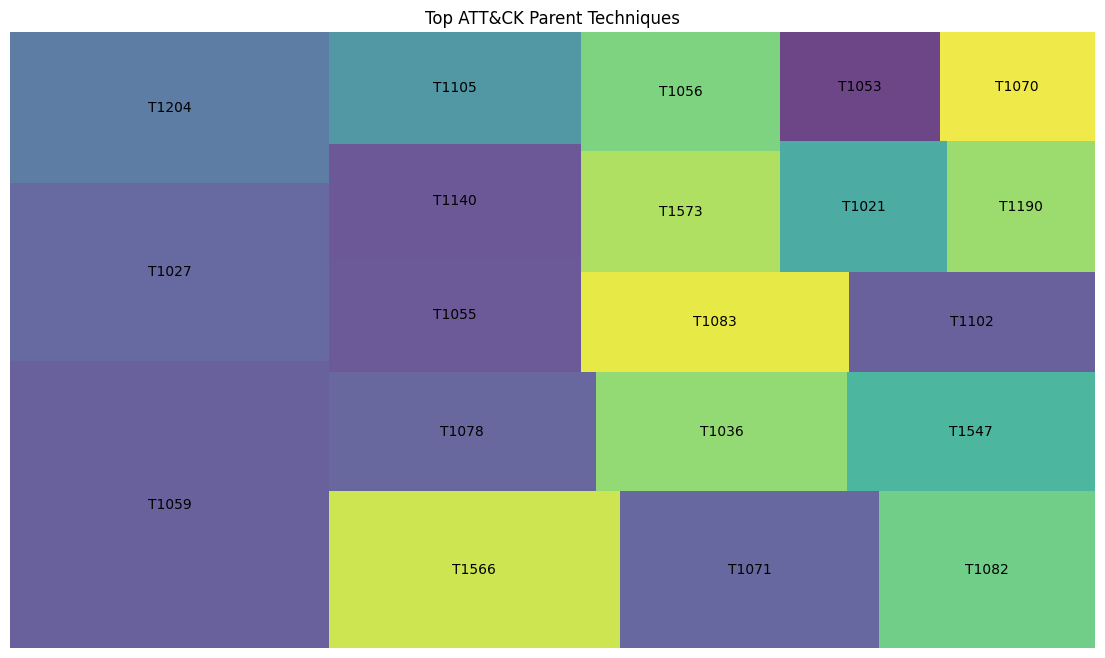

In [24]:
treemap_df = (attack_counts_table.groupby("Parent_Technique")["Count"].sum().sort_values(ascending = False).head(20))

plt.figure(figsize=(14,8))

squarify.plot(sizes = treemap_df.values, label = treemap_df.index, alpha = 0.8)

plt.title("Top ATT&CK Parent Techniques")
plt.axis("off")
plt.show()

In [25]:
# Parent Technique Count
attack_counts_table["Count"].describe()

count     554.000000
mean       50.861011
std       111.349573
min         1.000000
25%         2.000000
50%         8.000000
75%        44.250000
max      1011.000000
Name: Count, dtype: float64

In [26]:
sparse_subtechniques = attack_counts_table[(attack_counts_table["Is_Subtechnique"] == True) & (attack_counts_table["Count"] < 10)]
sparse_subtechniques.head(20)

,Attack_ID,Count,Parent_Technique,Is_Subtechnique
265,T1114.002,9,T1114,True
266,T1543.004,9,T1543,True
268,T1036.001,9,T1036,True
269,T1136.002,9,T1136,True
270,T1555.005,9,T1555,True
272,T1568.002,8,T1568,True
273,T1071.002,8,T1071,True
274,T1134.001,8,T1134,True
275,T1204.003,8,T1204,True
276,T1110.001,8,T1110,True


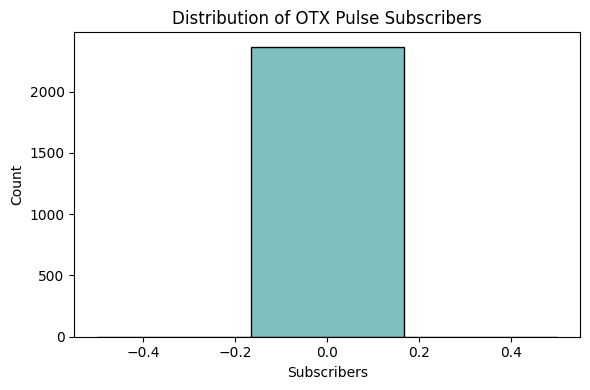

In [27]:
plt.figure(figsize=(6, 4))

sns.histplot(otx["Subscribers"], bins=3, kde=True, color="teal")

plt.title("Distribution of OTX Pulse Subscribers")

plt.tight_layout()
plt.show()

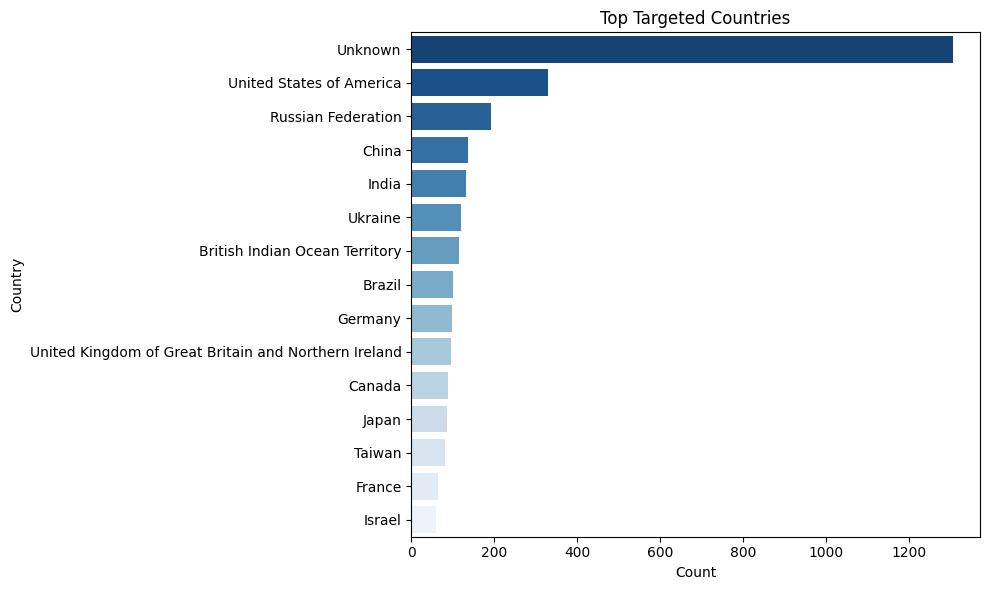

In [28]:
countries = ",".join(otx["Countries"].dropna()).split(",")

country_counts = Counter([c.strip() for c in countries])

top_countries = pd.DataFrame(country_counts.items(), columns=["Country", "Count"]).sort_values(by="Count", ascending=False).head(15)

plt.figure(figsize=(10, 6))

sns.barplot(data=top_countries, x="Count", y="Country", hue="Country", palette="Blues_r", legend=False)

plt.title("Top Targeted Countries")
plt.tight_layout()
plt.show()

#### 4. Malicious IPs ####

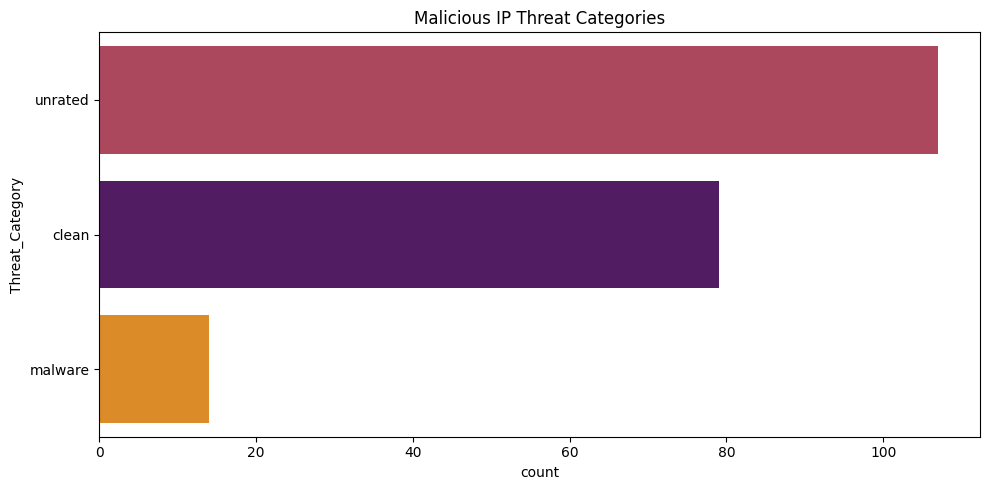

In [29]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data = ips,
    y = "Threat_Category",
    order = ips["Threat_Category"].value_counts().index,
    palette = "inferno",
    hue = "Threat_Category"
)

plt.title("Malicious IP Threat Categories")

plt.tight_layout()
plt.show()

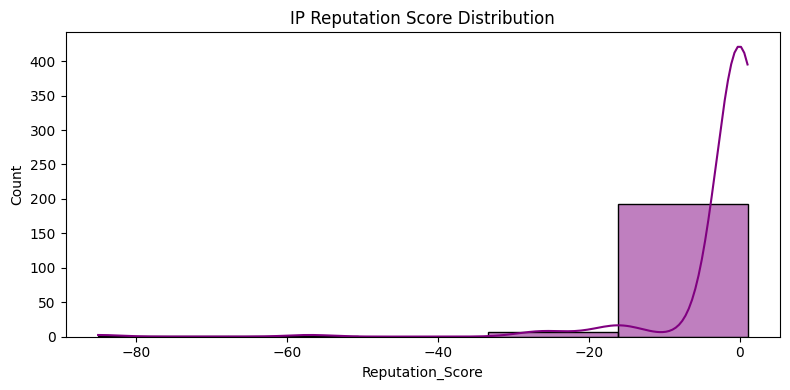

In [30]:
plt.figure(figsize=(8, 4))

sns.histplot(
    ips["Reputation_Score"],
    bins = 5,
    kde = True,
    color = "purple"
)

plt.title("IP Reputation Score Distribution")

plt.tight_layout()
plt.show()

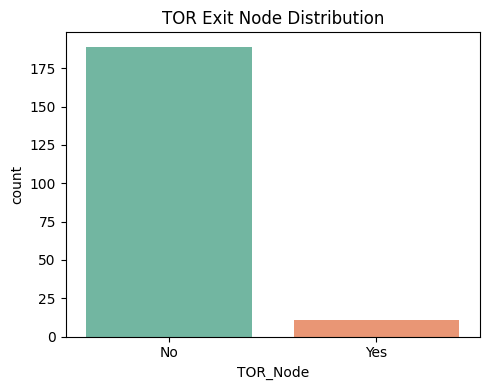

In [31]:
plt.figure(figsize=(5, 4))

sns.countplot(data = ips, x = "TOR_Node", palette="Set2", hue = "TOR_Node")

plt.title("TOR Exit Node Distribution")

plt.tight_layout()
plt.show()

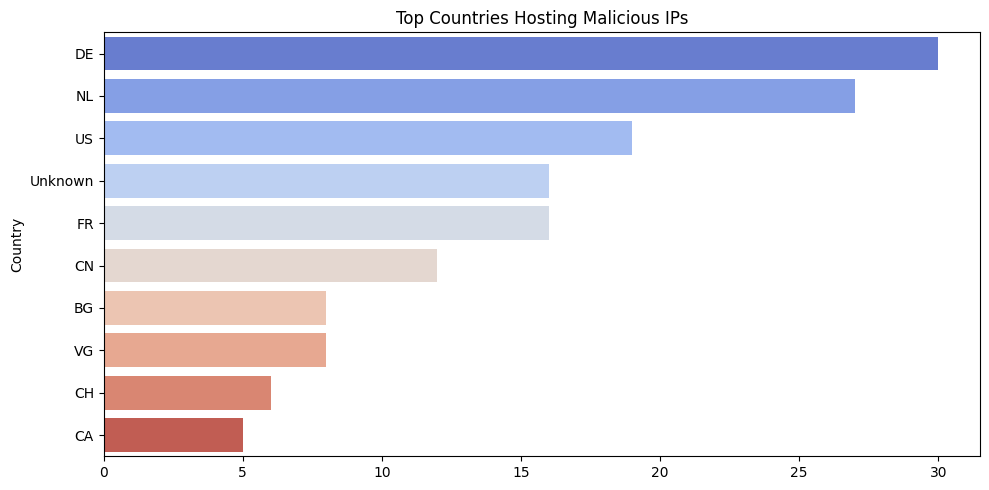

In [32]:
top_countries = ips["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x = top_countries.values,
    y = top_countries.index,
    hue = top_countries.index,
    palette="coolwarm"
)

plt.title("Top Countries Hosting Malicious IPs")

plt.tight_layout()
plt.show()

#### 5. Miscellaneous ####

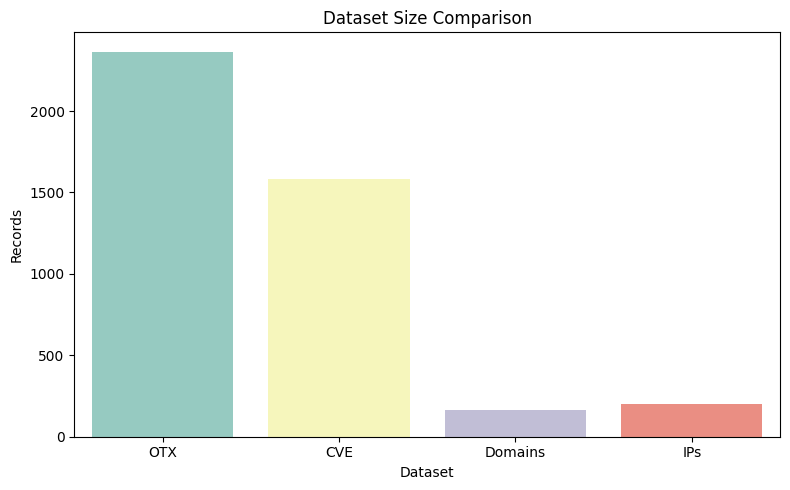

In [33]:
dataset_sizes = pd.DataFrame({
    "Dataset": ["OTX", "CVE", "Domains", "IPs"],
    "Records": [
        len(otx),
        len(cve),
        len(domains),
        len(ips)
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data = dataset_sizes,
    x = "Dataset",
    y = "Records",
    palette="Set3",
    hue = "Dataset"
)

plt.title("Dataset Size Comparison")

plt.tight_layout()
plt.show()

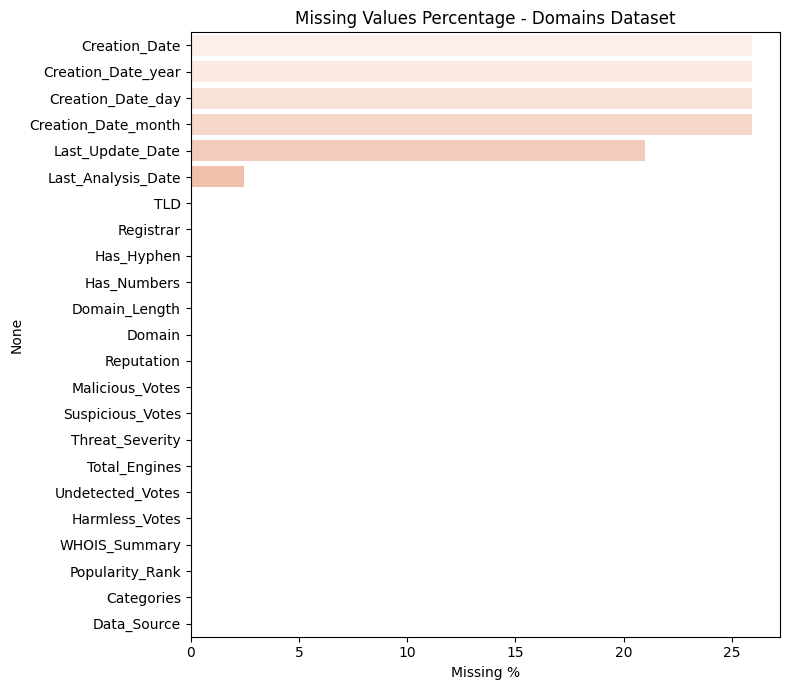

In [34]:
missing = pd.DataFrame({
    "Missing %": (
        domains.isnull().sum() / len(domains)
    ) * 100
}).sort_values(by="Missing %", ascending=False)

plt.figure(figsize=(8, 7))

sns.barplot(
    x = missing["Missing %"],
    y = missing.index,
    hue = missing.index,
    palette = "Reds",
    dodge = False,
    legend = False

)

plt.title("Missing Values Percentage - Domains Dataset")

plt.tight_layout()
plt.show()

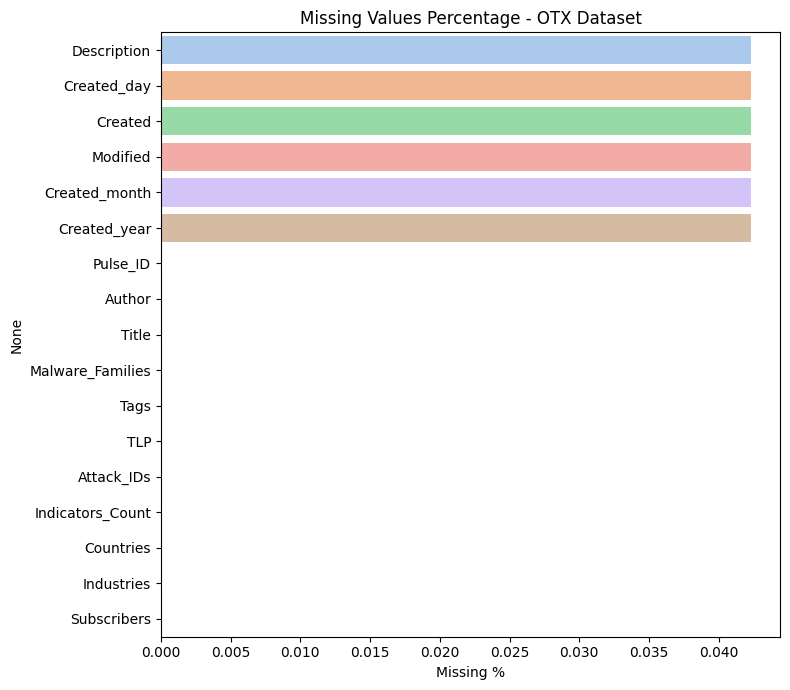

In [35]:
missing = pd.DataFrame({
    "Missing %": (
        otx.isnull().sum() / len(otx)
    ) * 100
}).sort_values(by="Missing %", ascending=False)

plt.figure(figsize=(8, 7))

sns.barplot(
    x = missing["Missing %"],
    y = missing.index,
    hue = missing.index,
    palette = "pastel",
    dodge = False,
    legend = False

)

plt.title("Missing Values Percentage - OTX Dataset")

plt.tight_layout()
plt.show()

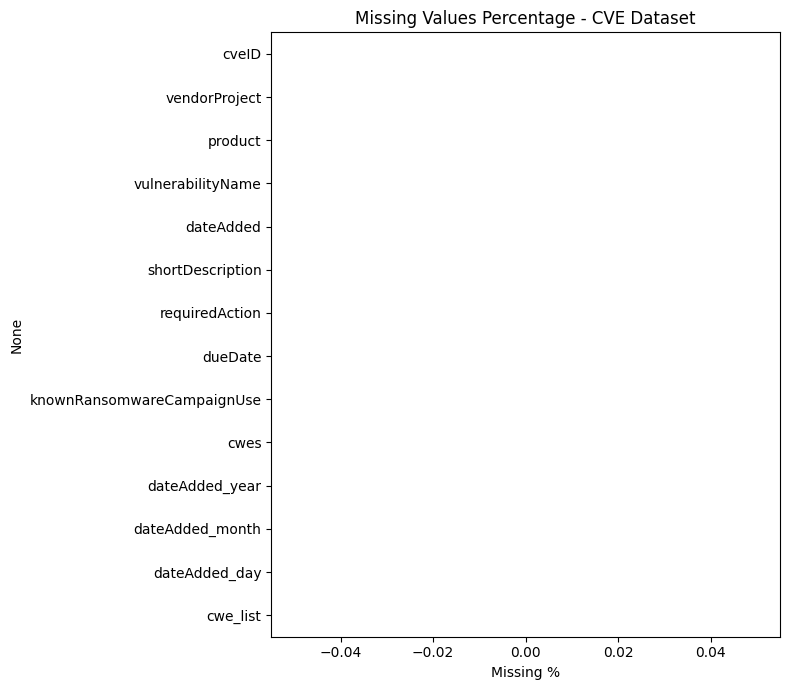

In [36]:
missing = pd.DataFrame({
    "Missing %": (
        cve.isnull().sum() / len(cve)
    ) * 100
}).sort_values(by="Missing %", ascending=False)

plt.figure(figsize=(8, 7))

sns.barplot(
    x = missing["Missing %"],
    y = missing.index,
    hue = missing.index,
    palette = "deep",
    dodge = False,
    legend = False

)

plt.title("Missing Values Percentage - CVE Dataset")

plt.tight_layout()
plt.show()

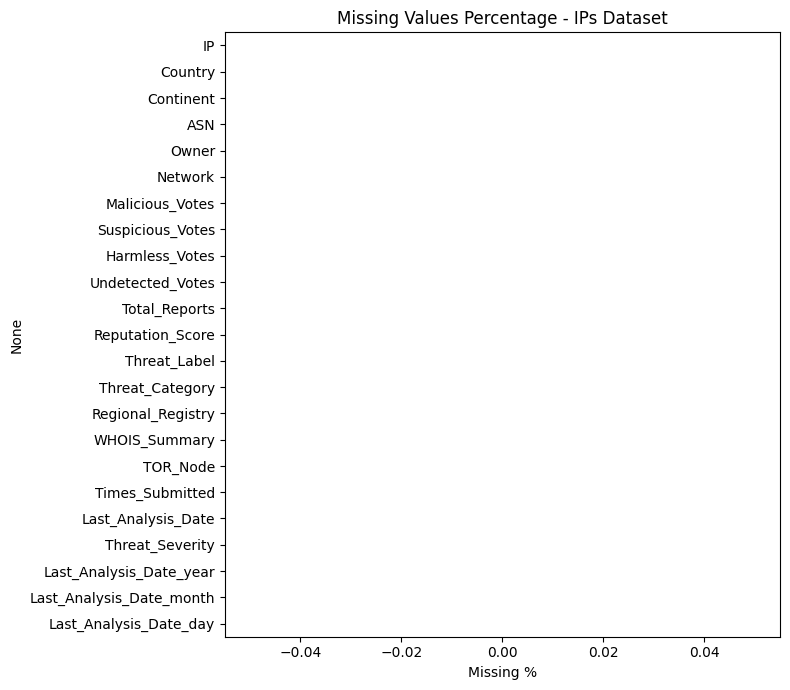

In [37]:
missing = pd.DataFrame({
    "Missing %": (
        ips.isnull().sum() / len(ips)
    ) * 100
}).sort_values(by="Missing %", ascending=False)

plt.figure(figsize=(8, 7))

sns.barplot(
    x = missing["Missing %"],
    y = missing.index,
    hue = missing.index,
    palette = "bright",
    dodge = False,
    legend = False

)

plt.title("Missing Values Percentage - IPs Dataset")

plt.tight_layout()
plt.show()

### Save Interim Cleaned Snapshots ###

In [38]:
otx.to_parquet(INTERIM_DIR / "otx_inspected.parquet", index=False)
cve.to_parquet(INTERIM_DIR / "cve_inspected.parquet", index=False)
domains.to_parquet(INTERIM_DIR / "domains_inspected.parquet", index=False)
ips.to_parquet(INTERIM_DIR / "ips_inspected.parquet", index=False)